In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rm1000_brain_tumor_mri_scans_path = kagglehub.dataset_download('rm1000/brain-tumor-mri-scans')
print(rm1000_brain_tumor_mri_scans_path)
print('Data source import complete.')


/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1
Data source import complete.


**Importing necessary libraries**

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import matplotlib.image as mpimg

**Showing Images of the Dataset**

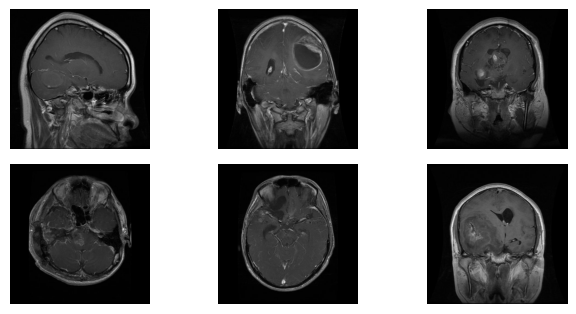

In [11]:
images_path = '/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/glioma/'
count = 0
for image_path in os.listdir(images_path):
    complete_path = os.path.join(images_path,image_path)
    image = Image.open(complete_path)
    plt.subplot(3,3,count+1)
    plt.imshow(image)
    plt.axis('off')
    count+=1
    if count==6:
        break
plt.axis('off')
plt.tight_layout()
plt.show()

**Data Augmentation using ImageDataGenerator**

In [13]:
image_generator = ImageDataGenerator(
    rotation_range=90,
    fill_mode='nearest',
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1./255,
    validation_split=0.2
)

**Creating Image Generators for Train and Validation Data**

In [14]:
path = '/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1'
train_data = image_generator.flow_from_directory(
    path,
    target_size=(512,512),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    subset='training'
)
validation_data = image_generator.flow_from_directory(
    path,
    target_size=(512,512),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    subset='validation'
)

Found 5619 images belonging to 4 classes.
Found 1404 images belonging to 4 classes.


**Showing some images from Train Data after Augmenation**

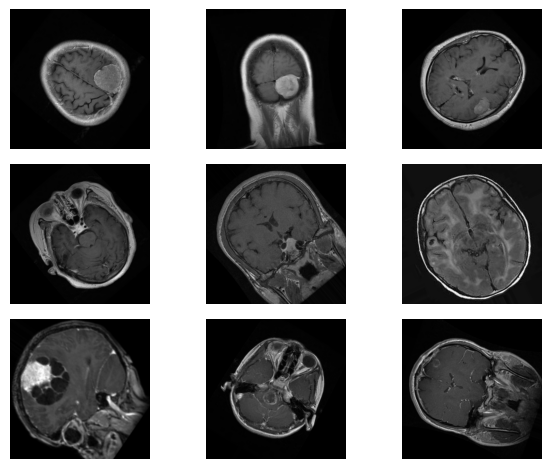

In [15]:
images,label = next(train_data)
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i]*255
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
plt.tight_layout()
plt.show()

**Creating the Model architecture using functional api**

In [16]:
input = layers.Input(shape=(512,512,3))
x = layers.Conv2D(32,(3,3),activation='relu')(input)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Conv2D(64,(3,3),activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Conv2D(128,(3,3),activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64,activation='relu')(x)
x = layers.Dense(32,activation='relu')(x)
output = layers.Dense(4,activation='softmax')(x)
model = Model(input,output)

**Model Summary**

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 512, 512, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 510, 510, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 255, 255, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 253, 253, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 126, 126, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 124, 124, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 62, 62, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 492032)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      31,490,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,585,572 (120.49 MB)

 Trainable params: 31,585,572 (120.49 MB)

 Non-trainable params: 0 (0.00 B)

**Compiling the model**

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Training the model**

In [19]:
history = model.fit(train_data,epochs=10,validation_data=[validation_data])

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


176/176 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.4991 - loss: 1.2540 - val_accuracy: 0.7030 - val_loss: 0.6985
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.7258 - loss: 0.6639 - val_accuracy: 0.8205 - val_loss: 0.4967
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7839 - loss: 0.5636 - val_accuracy: 0.7500 - val_loss: 0.5367
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.8069 - loss: 0.4934 - val_accuracy: 0.8198 - val_loss: 0.4394
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.7934 - loss: 0.4964 - val_accuracy: 0.8184 - val_loss: 0.4551
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.8233 - loss: 0.4423 - val_accuracy: 0.8155 - val_loss: 0.4413
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.8514 - loss: 0.3972 - val_accuracy: 0.8711 - val_loss: 0.3424
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.8626 - loss: 0.3682 - val_accuracy: 0.879

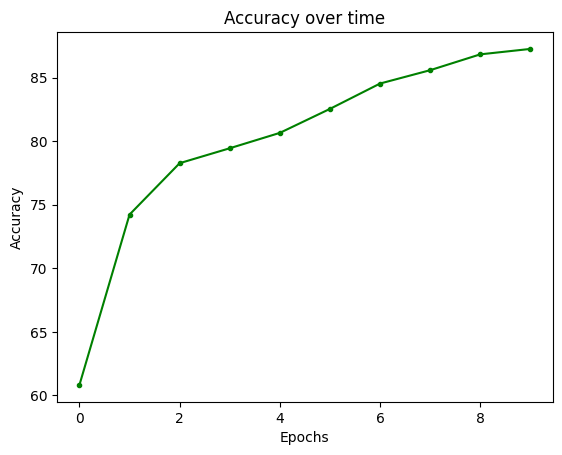

In [26]:
accuracy = history.history['accuracy']
accuracy = [x*100 for x in accuracy]
plt.plot(accuracy,color='green',marker='.')
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.title("Accuracy over time")
plt.show()

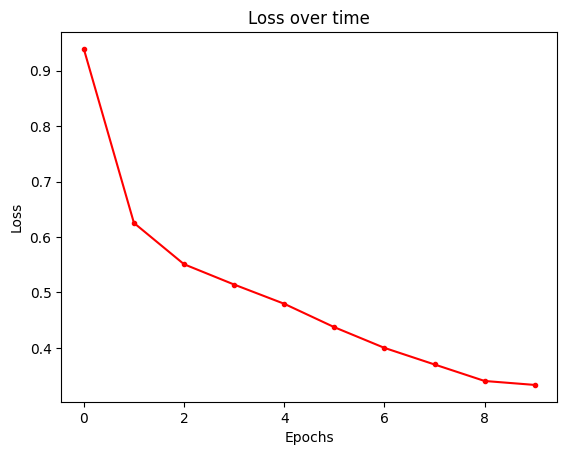

In [27]:
loss = history.history['loss']
plt.plot(loss,color='red',marker='.')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.show()

In [22]:
#Extracting Classes names
indices = train_data.class_indices
indices = list(indices.keys())

**Predictions on the first image from every class**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


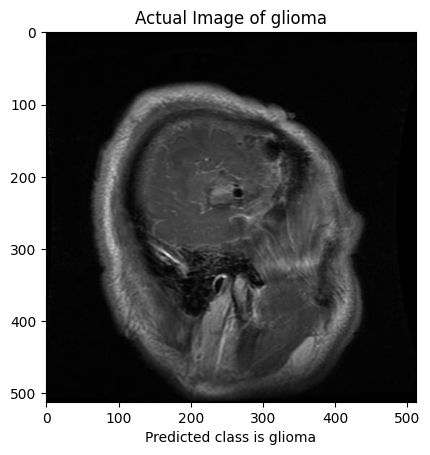

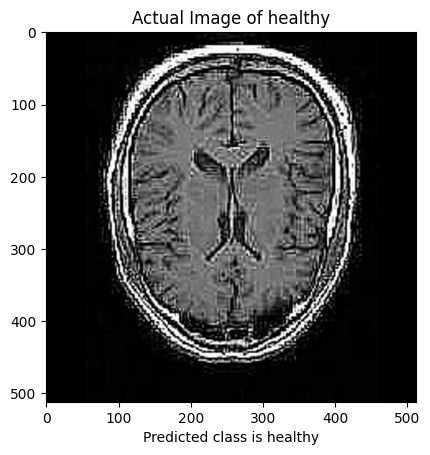

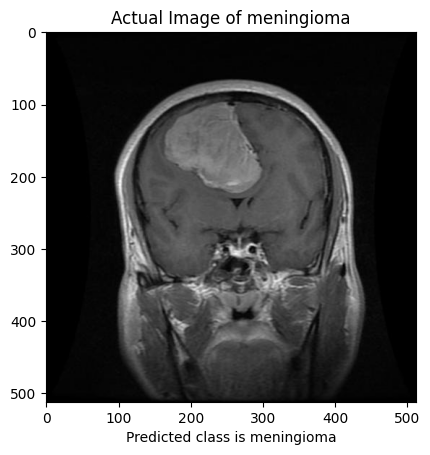

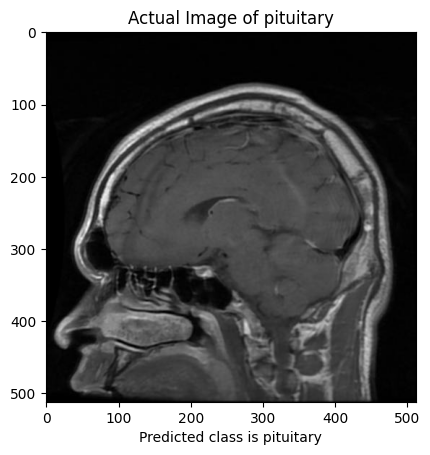

In [24]:
image_paths = ['/glioma/0000.jpg','/healthy/0000.jpg','/meningioma/0000.jpg','/pituitary/0000.jpg']
main_path = '/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1'
results = []
images = []
actual_classes = ['glioma','healthy','meningioma','pituitary']
for path in image_paths:
    image = main_path+path
    img = Image.open(image)
    img = img.resize((512,512))
    images.append(img)
    image = np.array(img)
    image = image/255.0
    image = np.expand_dims(image,axis=0)
    prediction = model.predict(image)
    results.append(np.argmax(prediction))
counter = 0
for image in images:
    plt.imshow(image)
    plt.title(f'Actual Image of {actual_classes[counter]}')
    plt.xlabel(f'Predicted class is {indices[counter]}')
    plt.show()
    counter+=1